# Lab Day 1 — Mạng nơ-ron và thí nghiệm huấn luyện (Forest CoverType)

**Họ tên / MSSV:** `2A202602796` · Notebook này chạy từ đầu đến cuối (*Restart & Run All*) từ thư mục `submission_2A202602796/code/`.

- Mọi thí nghiệm là **một lệnh `run(...)`** gọi `run_experiment(cfg, data)` — chỉ đổi dict cấu hình, mỗi lần đổi **một** yếu tố so với baseline.
- Mọi lựa chọn (lr, cấu hình cuối) được chọn **bằng val** *bằng code*; tập **eval** chỉ được dùng ở Part 4.
- Mỗi nhóm thí nghiệm có: **dự đoán trước** (ô markdown *trước* khi chạy) → chạy → **đối chiếu** (ô markdown *sau* khi chạy, bạn viết sau khi xem output).
- Đặt biến môi trường `LAB_QUICK=1` chỉ để kiểm tra nhanh code (2 epoch/lần chạy). **Khi nộp bài: không đặt**, để chạy đủ 20 epoch.

In [1]:
# ===== Cấu hình đường dẫn và môi trường =====
import os, sys, json, math, time, subprocess, tempfile
import numpy as np, pandas as pd, torch, torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import Image, display

QUICK = os.environ.get("LAB_QUICK") == "1"     # True = chỉ kiểm tra code (2 epoch). KHI NỘP BÀI phải là False.
EPOCHS = 2 if QUICK else 20                    # cùng số epoch cho mọi thí nghiệm (trừ thí nghiệm "epochs" ở hparam)

# Local: notebook nằm ở submission_<MSSV>/code/ nên repo gốc là ../..
# Colab: tự git clone repo vào /content, upload thư mục submission_<MSSV>/ vào gốc repo đó; ô này tự chuyển vào submission_*/code
import glob
IN_COLAB = "google.colab" in sys.modules
COLAB_REPO = "/content/K4-Track4-Day1-Neuralnetwork"
if IN_COLAB:
    if not os.path.exists(COLAB_REPO):
        subprocess.run(["git", "clone", "https://github.com/VinUni-AI20k/K4-Track4-Day1-Neuralnetwork.git", COLAB_REPO], check=True)
    if not os.path.exists("data.py"):
        os.chdir(sorted(glob.glob(f"{COLAB_REPO}/submission_*/code"))[0])
REPO_ROOT = next((r for r in ("../..", COLAB_REPO) if os.path.exists(f"{r}/scripts/split_data.py")), None)
assert REPO_ROOT, "Không tìm thấy repo (thư mục chứa scripts/split_data.py)"
OUT_DIR = ".."          # = submission_<MSSV>/ : nơi ghi figures/, results/, experiments.xlsx, predictions_eval.csv
sys.path.insert(0, os.getcwd())

device = "cuda" if torch.cuda.is_available() else ("mps" if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available() else "cpu")
print("torch", torch.__version__, "| device:", device, "|", torch.cuda.get_device_name(0) if device == "cuda" else "")
print("QUICK =", QUICK, "| EPOCHS =", EPOCHS)
os.makedirs(f"{OUT_DIR}/figures", exist_ok=True)
os.makedirs(f"{OUT_DIR}/results", exist_ok=True)

from data import prepare_data
from model import MLP, EXPECTED_PARAMS, count_params, init_weights, activation_stats
from optimizer import build_optimizer, clip_gradients
from train import DEFAULT_CFG, set_seed, evaluate, predict, run_experiment, final_eval
from plots import plot_run, plot_compare
from results_table import save_result, load_results, to_row, write_xlsx

torch 2.11.0+cu128 | device: cuda | NVIDIA GeForce RTX 4050 Laptop GPU
QUICK = False | EPOCHS = 20


## Part 0 — Dữ liệu
Chia train/eval bằng `data/split_metadata.csv` (không sửa, không tự chia lại) → tách validation 20% **từ train** (phân tầng, seed 42)
→ chuẩn hoá 10 cột số bằng mean/std của **phần train còn lại** → đưa lên device một lần.

In [2]:
subprocess.run([sys.executable, "scripts/split_data.py"], cwd=REPO_ROOT, check=True)
data = prepare_data(device, val_fraction=0.2, seed=42, processed_dir=f"{REPO_ROOT}/data/processed")

# --- kiểm tra Part 0
assert (len(data["X_tr"]), len(data["X_val"]), len(data["X_eval"])) == (371_847, 92_962, 116_203)
ratio = lambda y: np.bincount(y.cpu().numpy(), minlength=7) / len(y)
print(pd.DataFrame({"train": ratio(data["y_tr"]), "val": ratio(data["y_val"]), "eval": ratio(data["y_eval"])}).round(4).T.to_string())
num = data["X_tr"][:, :10]
print("10 cột số trên train còn lại: mean ≈", num.mean(0).abs().max().item(), "| std ≈", num.std(0).min().item(), "-", num.std(0).max().item())
print("val: mean(|.|) lớn nhất =", data["X_val"][:, :10].mean(0).abs().max().item(), "(không cần đúng 0: mean/std lấy từ train)")

train 371847 | val 92962 | eval 116203   (device=cuda)
'luôn đoán lớp đa số' (lớp 1) trên val: accuracy = 0.4876
            0       1       2       3       4       5       6
train  0.3646  0.4876  0.0615  0.0047  0.0163  0.0299  0.0353
val    0.3646  0.4876  0.0615  0.0047  0.0163  0.0299  0.0353
eval   0.3646  0.4876  0.0615  0.0047  0.0163  0.0299  0.0353
10 cột số trên train còn lại: mean ≈ 3.118669544832642e-09 | std ≈ 1.000001311302185 - 1.000001311302185
val: mean(|.|) lớn nhất = 0.006257375702261925 (không cần đúng 0: mean/std lấy từ train)


**Nhận xét Part 0 (tự viết):** train 371 847 / val 92 962 / eval 116 203; tỉ lệ 7 lớp ở train, val, eval trùng nhau tới 3–4 chữ số (phân tầng), mốc "đoán đa số" (lớp 1) = 0.4876 trên val. Không tính mean/std trên val/eval vì như vậy thông tin của tập đánh giá rò rỉ vào bước chuẩn hoá, làm ước lượng tốt hơn thực tế; mean/std chỉ lấy từ train (val có |mean| lớn nhất ≈ 0.006, không cần đúng 0).

## Part 1 — Model và kiểm tra "sức khoẻ" ban đầu
`M-base` = `54 → 256 → 128 → 7`, **47 879 tham số**, logits `(B, 7)`, không softmax trong model.

In [3]:
# 1b. shape và số tham số
set_seed(0)
model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
assert count_params(model) == EXPECTED_PARAMS[(256, 128)] == 47_879
h = torch.randn(8, 54, device=device)
for layer in model.net:
    h = layer(h); print(f"{type(layer).__name__:8s} -> {tuple(h.shape)}")
assert h.shape == (8, 7)
print("số tham số:", count_params(model))

Linear   -> (8, 256)


ReLU     -> (8, 256)
Linear   -> (8, 128)
ReLU     -> (8, 128)
Linear   -> (8, 7)
số tham số: 47879


In [4]:
# 1c-1. loss bước 0 trên val (eval mode) với vài cách khởi tạo
print(f"ln 7 = {math.log(7):.4f}")
for init in ("he", "default", "xavier", "normal", "zeros"):
    set_seed(0)
    m = MLP(init=init).to(device)
    print(f"init={init:8s} loss bước 0 trên val = {evaluate(m, data['X_val'], data['y_val'])['loss']:.4f}")

ln 7 = 1.9459
init=he       loss bước 0 trên val = 2.2073
init=default  loss bước 0 trên val = 1.8922
init=xavier   loss bước 0 trên val = 1.9973
init=normal   loss bước 0 trên val = 1.9460
init=zeros    loss bước 0 trên val = 1.9459


loss đầu = 2.2808 | loss sau 400 bước = 1.94e-04 | accuracy trên 20 mẫu = 1.00


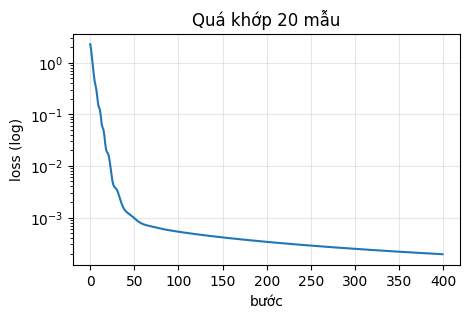

net.0.weight shape=(256, 54)    ‖grad‖ = 0.4543
net.0.bias   shape=(256,)       ‖grad‖ = 0.2684
net.2.weight shape=(128, 256)   ‖grad‖ = 1.7565
net.2.bias   shape=(128,)       ‖grad‖ = 0.3824
net.4.weight shape=(7, 128)     ‖grad‖ = 1.9387
net.4.bias   shape=(7,)         ‖grad‖ = 0.5498


In [5]:
# 1c-2. quá khớp 20 mẫu (tắt dropout, vài trăm bước): loss phải về gần 0, accuracy 100%
set_seed(0)
m = MLP(init="he").to(device)
opt = build_optimizer("sgd_momentum", m.parameters(), lr=0.05)
idx = torch.randperm(len(data["X_tr"]), device=device)[:20]
xb, yb = data["X_tr"][idx], data["y_tr"][idx]
curve = []
for step in range(400):
    loss = F.cross_entropy(m(xb), yb); opt.zero_grad(); loss.backward(); opt.step(); curve.append(loss.item())
acc20 = (m(xb).argmax(1) == yb).float().mean().item()
print(f"loss đầu = {curve[0]:.4f} | loss sau 400 bước = {curve[-1]:.2e} | accuracy trên 20 mẫu = {acc20:.2f}")
plt.figure(figsize=(5, 3)); plt.semilogy(curve); plt.xlabel("bước"); plt.ylabel("loss (log)"); plt.title("Quá khớp 20 mẫu"); plt.grid(alpha=.3); plt.show()
assert curve[-1] < 0.05 and acc20 == 1.0, "không quá khớp được 20 mẫu -> gần như chắc chắn lỗi code"

# 1d. gradient có chảy tới mọi tham số không?
set_seed(0)
m = MLP(init="he").to(device)
F.cross_entropy(m(data["X_tr"][:512]), data["y_tr"][:512]).backward()
for name, p in m.named_parameters():
    assert p.grad is not None and p.grad.norm() > 0, f"{name}: không có gradient"
    print(f"{name:12s} shape={tuple(p.shape)!s:12s} ‖grad‖ = {p.grad.norm().item():.4f}")

**Nhận xét Part 1 (tự viết):** loss bước 0 đo được = 2.207 (He, trên val) so với ln 7 = 1.946: với He init lớp cuối cũng có phương sai `2/n_in` nên logit ban đầu lớn hơn khởi tạo "nhỏ" → loss bước 0 cao hơn ln 7 (xavier 1.997, default 1.892, normal/zeros ≈ 1.946); quá khớp 20 mẫu: loss 2.28 → 1.9e-4 sau 400 bước, accuracy 1.00 (code đúng, mô hình đủ năng lực); mọi tham số đều có gradient khác 0: có (‖grad‖ từ 0.27 đến 1.94 ở cả 6 tensor).

## Part 2 — Pipeline và baseline
`run_experiment(cfg, data)` nhận dict cấu hình, trả về lịch sử + tóm tắt. Baseline: `M-base`, SGD+momentum 0.9, CE, He, batch 512, 20 epoch, dropout 0, không clip, FP32.

**Chọn lr cho baseline bằng val:** quét SGD+momentum lr ∈ {0.01, 0.03, 0.1, 0.3} (các lần chạy này cũng là một phần của nhóm *optimizer*).

In [6]:
RESULTS, RUN_ORDER = {}, []      # exp_id -> result đầy đủ (kể cả best_state, giữ trong RAM để dự đoán eval)

def run(show=False, **kw):
    """Một thí nghiệm = một dict cfg (đè lên DEFAULT_CFG/BASE). Lưu results/<exp_id>.json và figures/<exp_id>.png."""
    cfg = {**BASE, **kw}
    assert cfg["exp_id"] not in RESULTS, f"exp_id trùng: {cfg['exp_id']}"
    r = run_experiment(cfg, data)
    save_result(r, f"{OUT_DIR}/results"); plot_run(r, f"{OUT_DIR}/figures/{cfg['exp_id']}.png")
    RESULTS[cfg["exp_id"]] = r; RUN_ORDER.append(cfg["exp_id"])
    s = r["summary"]; f = lambda v, p=4: "None" if v is None else f"{v:.{p}f}"
    print(f"{cfg['exp_id']:24s} val_f1={f(s['val_macro_f1'])} val_acc={f(s['val_acc'])} best_vloss={f(s['best_val_loss'])} "
          f"best_ep={s['best_epoch']} step0={f(s['step0_loss'], 3)} t/ep={s['time_per_epoch_s']:.2f}s"
          + ("  [DIVERGED]" if s["diverged"] else ""))
    if show: display(Image(f"{OUT_DIR}/figures/{cfg['exp_id']}.png"))
    return r

def val_f1(i):  # val macro-F1 tại best epoch; run bị diverged -> -inf (không bao giờ được chọn)
    v = RESULTS[i]["summary"]["val_macro_f1"]
    return -np.inf if v is None else v

def best_of(ids): return max(ids, key=val_f1)

def compare_table(ids, ref_mean=None, noise2=None):
    rows = []
    for i in ids:
        c, s = RESULTS[i]["cfg"], RESULTS[i]["summary"]
        d = None if (ref_mean is None or s["val_macro_f1"] is None) else s["val_macro_f1"] - ref_mean
        rows.append(dict(exp_id=i, opt=c["optimizer"], lr=c["lr"], val_f1=s["val_macro_f1"], val_acc=s["val_acc"],
                         best_vloss=s["best_val_loss"], best_ep=s["best_epoch"], gap=None if s["final_val_loss"] is None else s["final_val_loss"] - s["final_train_loss"],
                         t_ep=s["time_per_epoch_s"], delta_vs_base=d, beyond_2sigma=None if d is None or noise2 is None else abs(d) > noise2))
    return pd.DataFrame(rows).set_index("exp_id").round(4)

In [7]:
BASE = {**DEFAULT_CFG, "epochs": EPOCHS, "lr": 0.05}   # lr tạm thời, chỉ để chạy các lần quét lr bên dưới
SGDM_LRS = [0.01, 0.03, 0.1, 0.3]
for lr in SGDM_LRS:
    run(exp_id=f"opt-sgdm-lr{lr:g}", group="optimizer", description=f"SGD+momentum, lr={lr:g} (quét lr để chọn lr baseline)", lr=lr)
sgdm_ids = [f"opt-sgdm-lr{lr:g}" for lr in SGDM_LRS]
BASE_LR = RESULTS[best_of(sgdm_ids)]["cfg"]["lr"]            # chọn bằng VAL macro-F1 (không dùng eval)
print("\n-> lr baseline (chọn theo val macro-F1) =", BASE_LR)
compare_table(sgdm_ids)

opt-sgdm-lr0.01          val_f1=0.7607 val_acc=0.8710 best_vloss=0.3148 best_ep=20 step0=2.269 t/ep=1.15s


opt-sgdm-lr0.03          val_f1=0.8244 val_acc=0.8934 best_vloss=0.2638 best_ep=20 step0=2.269 t/ep=1.13s


opt-sgdm-lr0.1           val_f1=0.8541 val_acc=0.9081 best_vloss=0.2263 best_ep=19 step0=2.269 t/ep=1.17s


opt-sgdm-lr0.3           val_f1=0.8597 val_acc=0.9132 best_vloss=0.2208 best_ep=20 step0=2.269 t/ep=1.17s

-> lr baseline (chọn theo val macro-F1) = 0.3


,opt,lr,val_f1,val_acc,best_vloss,best_ep,gap,t_ep,delta_vs_base,beyond_2sigma
exp_id,,,,,,,,,,
opt-sgdm-lr0.01,sgd_momentum,0.01,0.7607,0.8710,0.3148,20,0.0099,1.1541,None,None
opt-sgdm-lr0.03,sgd_momentum,0.03,0.8244,0.8934,0.2638,20,0.0144,1.1331,None,None
opt-sgdm-lr0.1,sgd_momentum,0.10,0.8541,0.9081,0.2263,19,0.0197,1.1680,None,None
opt-sgdm-lr0.3,sgd_momentum,0.30,0.8597,0.9132,0.2208,20,0.0205,1.1725,None,None


base-s1                  val_f1=0.8597 val_acc=0.9132 best_vloss=0.2208 best_ep=20 step0=2.269 t/ep=1.14s


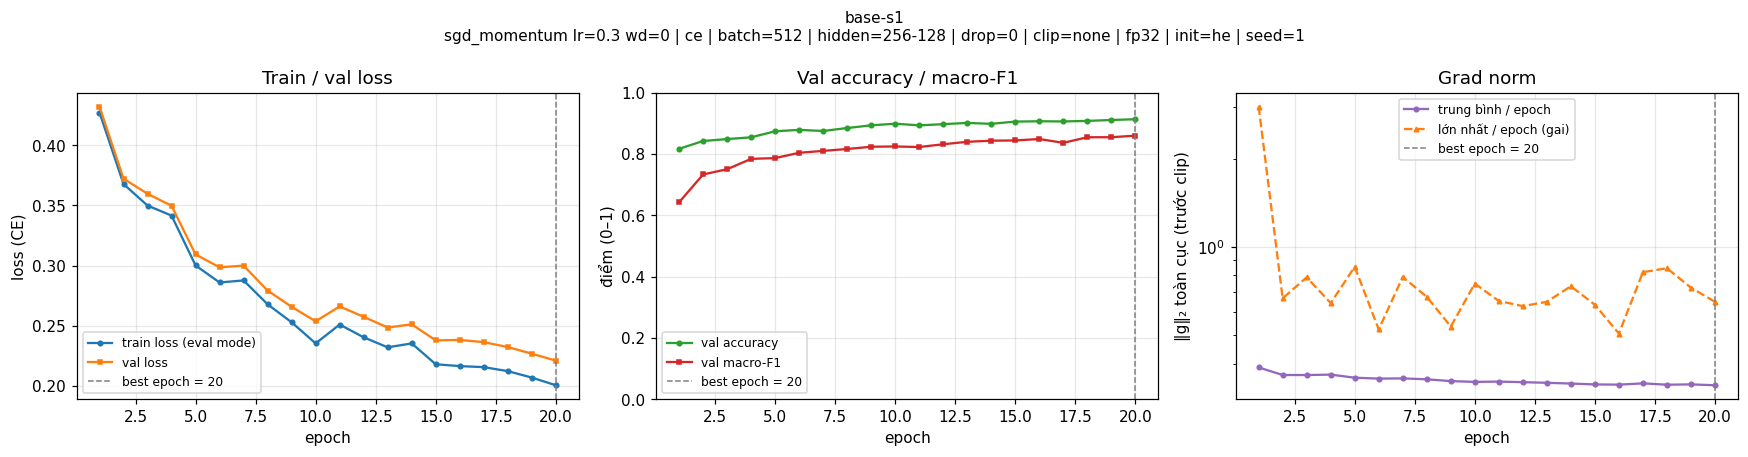

base-s2                  val_f1=0.8630 val_acc=0.9119 best_vloss=0.2233 best_ep=20 step0=1.978 t/ep=1.13s


base-s3                  val_f1=0.8597 val_acc=0.9138 best_vloss=0.2161 best_ep=19 step0=1.901 t/ep=1.12s


base-s4                  val_f1=0.8509 val_acc=0.9122 best_vloss=0.2225 best_ep=17 step0=2.311 t/ep=1.13s


base-s5                  val_f1=0.8643 val_acc=0.9146 best_vloss=0.2155 best_ep=19 step0=2.144 t/ep=1.10s

baseline (5 seed): val macro-F1 = 0.8595 ± 0.0052 | val acc = 0.9131 ± 0.0011 | ngưỡng nhiễu 2σ = 0.0105
mốc 'đoán đa số' acc = 0.4876; val acc baseline > mốc: True
tái lập: val_f1 của opt-sgdm-lr0.3 = 0.859692 vs base-s1 = 0.859692 (cùng cfg, cùng seed)


,opt,lr,val_f1,val_acc,best_vloss,best_ep,gap,t_ep,delta_vs_base,beyond_2sigma
exp_id,,,,,,,,,,
base-s1,sgd_momentum,0.3,0.8597,0.9132,0.2208,20,0.0205,1.1406,0.0002,False
base-s2,sgd_momentum,0.3,0.8630,0.9119,0.2233,20,0.0255,1.1274,0.0035,False
base-s3,sgd_momentum,0.3,0.8597,0.9138,0.2161,19,0.0215,1.1238,0.0002,False
base-s4,sgd_momentum,0.3,0.8509,0.9122,0.2225,17,0.0213,1.1294,-0.0086,False
base-s5,sgd_momentum,0.3,0.8643,0.9146,0.2155,19,0.0200,1.1011,0.0048,False


In [8]:
BASE = {**DEFAULT_CFG, "epochs": EPOCHS, "lr": BASE_LR}   # BASELINE chính thức
N_SEEDS = 5                                              # 5 seed baseline -> σ_seed (sheet Seeds có 5 dòng)
for s in range(1, N_SEEDS + 1):
    run(exp_id=f"base-s{s}", group="baseline", description=f"Baseline M-base, seed {s}", seed=s, show=(s == 1))
base_ids = [f"base-s{s}" for s in range(1, N_SEEDS + 1)]
f1s = np.array([RESULTS[i]["summary"]["val_macro_f1"] for i in base_ids]); accs = np.array([RESULTS[i]["summary"]["val_acc"] for i in base_ids])
BASE_F1, SIGMA = f1s.mean(), f1s.std(ddof=1); NOISE2 = 2 * SIGMA
print(f"\nbaseline ({N_SEEDS} seed): val macro-F1 = {BASE_F1:.4f} ± {SIGMA:.4f} | val acc = {accs.mean():.4f} ± {accs.std(ddof=1):.4f} | ngưỡng nhiễu 2σ = {NOISE2:.4f}")
print(f"mốc 'đoán đa số' acc = {data['majority_acc_val']:.4f}; val acc baseline > mốc: {accs.min() > data['majority_acc_val']}")
# base-s1 lặp lại đúng cfg+seed của opt-sgdm-lr<BASE_LR> => kiểm tra tính tái lập
a, b = RESULTS[f"opt-sgdm-lr{BASE_LR:g}"]["summary"]["val_macro_f1"], RESULTS["base-s1"]["summary"]["val_macro_f1"]
print(f"tái lập: val_f1 của opt-sgdm-lr{BASE_LR:g} = {a:.6f} vs base-s1 = {b:.6f} (cùng cfg, cùng seed)")
compare_table(base_ids, BASE_F1, NOISE2)

**Nhận xét baseline (tự viết):** hình dạng đường cong (`figures/base-s1.png`): train/val loss vẫn đang giảm ở epoch 20 (best epoch 20; các seed 17–20), khoảng cách train–val ≈ 0.02 → chưa quá khớp, chưa hội tụ hẳn; val acc 0.913 so với mốc đoán đa số 0.4876; độ nhiễu giữa seed (val macro-F1): TB = 0.8595, σ = 0.0052, 2σ = 0.0105 (sẽ dùng làm ngưỡng cho mọi so sánh bên dưới). Các cấu hình 20 epoch chưa hội tụ hẳn (best epoch ≈ cuối).

## Part 3 — Thí nghiệm
Mỗi nhóm: **dự đoán trước** → chạy → **đối chiếu**. Một nhóm "vượt nhiễu" khi |Δ val macro-F1 so với trung bình baseline| > 2σ (cột `beyond_2sigma`).

### 3.1 Bộ tối ưu hoá (`optimizer`)
**Dự đoán trước (viết trước khi chạy):**
- Nếu lr tốt nhất nằm ở mép lưới (lr nhỏ nhất/lớn nhất), hãy mở rộng lưới rồi chạy lại. Plain SGD (không momentum) với cùng lr sẽ chậm hơn SGD+momentum ~10 lần (momentum 0.9 làm bước hiệu dụng ≈ lr/(1−0.9)), nên cần lr lớn hơn nhiều mới bằng; sau 20 epoch có thể kém hơn.
- Adam/AdamW chia bước theo độ lớn gradient từng tham số → hội tụ nhanh hơn ở các epoch đầu và ít nhạy với tỉ lệ tuỳ chỉnh của đặc trưng; ở lr tốt nhất mỗi bộ, Adam/AdamW sẽ nhỉnh hơn SGD+momentum, nhưng chênh lệch có thể nhỏ.
- Quá lớn lr làm Adam dao động (lr=3e-3 trở lên); quá nhỏ (1e-4) thì chưa hội tụ trong 20 epoch.
- AdamW với `weight_decay=0` ≡ Adam (cho cùng kết quả); với `weight_decay=0.01` khác biệt rất nhỏ vì mô hình chưa quá khớp.

In [9]:
OPT_GRID = {"sgd": [0.1, 0.3, 1.0], "adam": [1e-4, 3e-4, 1e-3, 3e-3, 1e-2], "adamw": [1e-4, 3e-4, 1e-3, 3e-3, 1e-2]}
for opt_name, lrs in OPT_GRID.items():
    for lr in lrs:
        run(exp_id=f"opt-{opt_name}-lr{lr:g}", group="optimizer", optimizer=opt_name, lr=lr,
            weight_decay=0.01 if opt_name == "adamw" else 0.0,
            description=f"{opt_name}, lr={lr:g}" + (", weight_decay=0.01" if opt_name == "adamw" else ""))

ids_by_opt = {"sgd_momentum": sgdm_ids, **{o: [f"opt-{o}-lr{lr:g}" for lr in l] for o, l in OPT_GRID.items()}}
BEST_ID = {o: best_of(ids) for o, ids in ids_by_opt.items()}          # lr tốt nhất của MỖI bộ tối ưu (theo val)
print("\nlr tốt nhất mỗi bộ:", {o: RESULTS[i]["cfg"]["lr"] for o, i in BEST_ID.items()})

# kiểm chứng "AdamW với weight_decay=0 ≡ Adam" ở lr tốt nhất của Adam
run(exp_id="opt-adamw-wd0", group="optimizer", optimizer="adamw", lr=RESULTS[BEST_ID["adam"]]["cfg"]["lr"], weight_decay=0.0,
    description="AdamW weight_decay=0 (phải trùng Adam cùng lr)")
print("Adam:", RESULTS[BEST_ID["adam"]]["summary"]["val_macro_f1"], "| AdamW(wd=0):", RESULTS["opt-adamw-wd0"]["summary"]["val_macro_f1"])
opt_all = [i for i in RUN_ORDER if i.startswith("opt-")]
compare_table(opt_all, BASE_F1, NOISE2)

opt-sgd-lr0.1            val_f1=0.7362 val_acc=0.8527 best_vloss=0.3531 best_ep=18 step0=2.269 t/ep=1.10s


opt-sgd-lr0.3            val_f1=0.7882 val_acc=0.8795 best_vloss=0.2935 best_ep=19 step0=2.269 t/ep=1.12s


opt-sgd-lr1              val_f1=0.8409 val_acc=0.9049 best_vloss=0.2380 best_ep=19 step0=2.269 t/ep=1.16s


opt-adam-lr0.0001        val_f1=0.7137 val_acc=0.8351 best_vloss=0.4001 best_ep=20 step0=2.269 t/ep=1.37s


opt-adam-lr0.0003        val_f1=0.7942 val_acc=0.8759 best_vloss=0.3092 best_ep=20 step0=2.269 t/ep=1.31s


...

opt-adamw-lr0.001        val_f1=0.8473 val_acc=0.9034 best_vloss=0.2430 best_ep=20 step0=2.269 t/ep=1.41s


opt-adamw-lr0.003        val_f1=0.8661 val_acc=0.9123 best_vloss=0.2161 best_ep=19 step0=2.269 t/ep=1.42s


opt-adamw-lr0.01         val_f1=0.8582 val_acc=0.9054 best_vloss=0.2356 best_ep=20 step0=2.269 t/ep=1.32s

lr tốt nhất mỗi bộ: {'sgd_momentum': 0.3, 'sgd': 1.0, 'adam': 0.003, 'adamw': 0.003}


opt-adamw-wd0            val_f1=0.8840 val_acc=0.9183 best_vloss=0.2052 best_ep=20 step0=2.269 t/ep=1.37s
Adam: 0.8840417760563263 | AdamW(wd=0): 0.8840417760563263


,opt,lr,val_f1,val_acc,best_vloss,best_ep,gap,t_ep,delta_vs_base,beyond_2sigma
exp_id,,,,,,,,,,
opt-sgdm-lr0.01,sgd_momentum,0.0100,0.7607,0.8710,0.3148,20,0.0099,1.1541,-0.0988,True
opt-sgdm-lr0.03,sgd_momentum,0.0300,0.8244,0.8934,0.2638,20,0.0144,1.1331,-0.0351,True
opt-sgdm-lr0.1,sgd_momentum,0.1000,0.8541,0.9081,0.2263,19,0.0197,1.1680,-0.0054,False
opt-sgdm-lr0.3,sgd_momentum,0.3000,0.8597,0.9132,0.2208,20,0.0205,1.1725,0.0002,False
opt-sgd-lr0.1,sgd,0.1000,0.7362,0.8527,0.3531,18,0.0063,1.0952,-0.1234,True
opt-sgd-lr0.3,sgd,0.3000,0.7882,0.8795,0.2935,19,0.0112,1.1224,-0.0714,True
opt-sgd-lr1,sgd,1.0000,0.8409,0.9049,0.2380,19,0.0194,1.1556,-0.0186,True
opt-adam-lr0.0001,adam,0.0001,0.7137,0.8351,0.4001,20,0.0061,1.3685,-0.1458,True
opt-adam-lr0.0003,adam,0.0003,0.7942,0.8759,0.3092,20,0.0112,1.3100,-0.0653,True


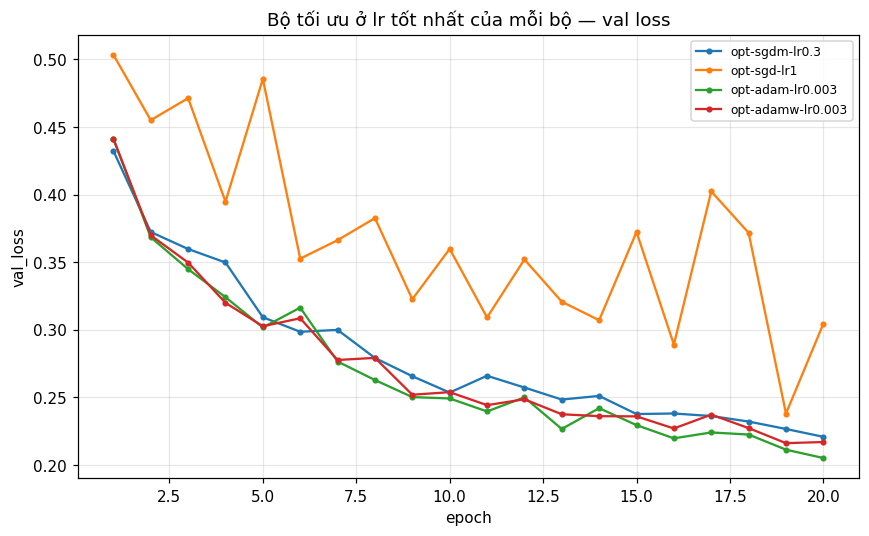

In [10]:
plot_compare([RESULTS[i] for i in BEST_ID.values()], "val_loss", f"{OUT_DIR}/figures/compare_optimizer.png", "Bộ tối ưu ở lr tốt nhất của mỗi bộ — val loss")
for o, ids in ids_by_opt.items():   # độ nhạy với lr của từng bộ
    plot_compare([RESULTS[i] for i in ids], "val_macro_f1", f"{OUT_DIR}/figures/compare_lr_{o}.png", f"{o}: val macro-F1 theo lr")
display(Image(f"{OUT_DIR}/figures/compare_optimizer.png"))

**Đối chiếu (viết sau khi chạy):** Adam (lr 3e-3) thắng: val macro-F1 0.884 vs SGD+momentum 0.860 (+0.024 > 2σ), AdamW 0.866, SGD 0.841. Adam chia bước theo độ lớn gradient từng tham số nên hội tụ nhanh hơn trong 20 epoch (khớp dự đoán). Độ nhạy lr: Adam ổn định trên 1e-3…1e-2 (đỉnh 3e-3, giữa lưới; 1e-4 → 0.714 chưa hội tụ), còn SGD và SGD+momentum tăng đều theo lr và lr tốt nhất nằm **ở mép trên lưới** (1 và 0.3) nên kết luận chỉ là cận dưới, có thể cần mở rộng lưới. SGD lr 1 ≈ SGDM lr 0.1 (0.841 vs 0.854), đúng dự đoán bước hiệu dụng ×10 do momentum. Adam vs AdamW(wd=0): trùng nhau hoàn toàn (0.8840) như dự đoán; AdamW(wd=0.01) thấp hơn Adam 0.018, nhưng chỉ 1 seed nên không chắc đó là tác dụng thật; khác dự đoán "chênh rất nhỏ".

### 3.2 Hàm mất mát (`loss`) — CE vs MSE (trên one-hot)
**Dự đoán trước:** MSE (`nn.MSELoss`: trung bình bình phương trên mọi phần tử B×7, không hệ số ½, không softmax) có gradient theo logit `2(z−y)/(7B)` nhỏ hơn và **không bão hoà** theo hướng ngược lại với CE (`softmax−y`, độ lớn ≤ 1/B mỗi phần tử),
nên ở cùng lr MSE học chậm hơn CE rõ rệt; cần lr lớn hơn (≈ 3–10×) để bắt kịp, và vẫn có thể kém hơn CE về macro-F1 (lớp hiếm) trong 20 epoch. **Không so loss trực tiếp** (khác thang đo): so val acc, macro-F1 và tốc độ hội tụ.

loss-mse-lr0.3           val_f1=0.7880 val_acc=0.8837 best_vloss=0.0272 best_ep=19 step0=0.636 t/ep=1.69s


loss-mse-lr0.9           val_f1=0.7061 val_acc=0.8371 best_vloss=0.0373 best_ep=20 step0=0.636 t/ep=1.61s


loss-mse-lr3             val_f1=None val_acc=None best_vloss=None best_ep=None step0=0.636 t/ep=0.10s  [DIVERGED]


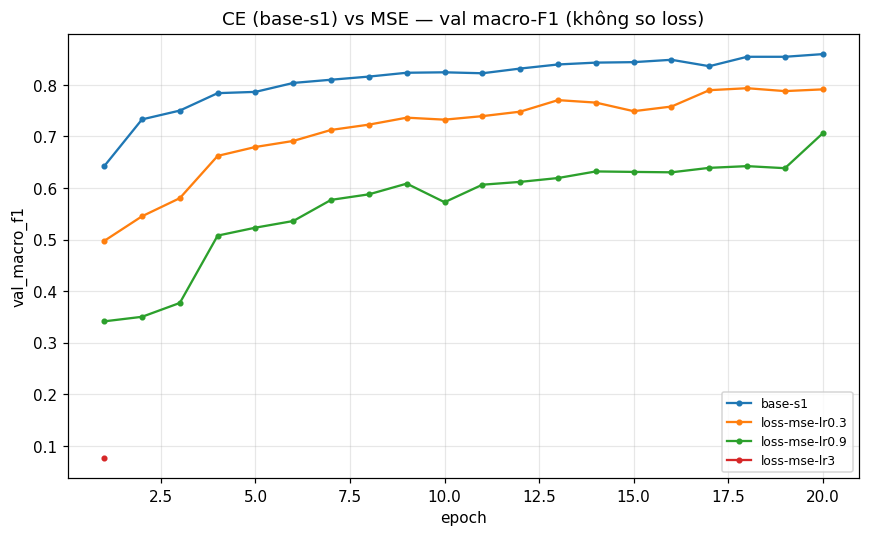

,opt,lr,val_f1,val_acc,best_vloss,best_ep,gap,t_ep,delta_vs_base,beyond_2sigma
exp_id,,,,,,,,,,
base-s1,sgd_momentum,0.3,0.8597,0.9132,0.2208,20.0,0.0205,1.1406,0.0002,False
loss-mse-lr0.3,sgd_momentum,0.3,0.7880,0.8837,0.0272,19.0,0.0009,1.6936,-0.0716,True
loss-mse-lr0.9,sgd_momentum,0.9,0.7061,0.8371,0.0373,20.0,0.0005,1.6117,-0.1534,True
loss-mse-lr3,sgd_momentum,3.0,NaN,NaN,NaN,NaN,NaN,0.0977,NaN,None


In [11]:
for m in (1, 3, 10):
    run(exp_id=f"loss-mse-lr{BASE_LR * m:g}", group="loss", loss="mse", lr=BASE_LR * m,
        description=f"MSE trên one-hot, lr={BASE_LR * m:g} (baseline lr ×{m})")
loss_ids = [i for i in RUN_ORDER if i.startswith("loss-")]
plot_compare([RESULTS["base-s1"]] + [RESULTS[i] for i in loss_ids], "val_macro_f1", f"{OUT_DIR}/figures/compare_loss.png", "CE (base-s1) vs MSE — val macro-F1 (không so loss)")
display(Image(f"{OUT_DIR}/figures/compare_loss.png"))
compare_table(["base-s1"] + loss_ids, BASE_F1, NOISE2)

**Đối chiếu (viết sau khi chạy):** CE tốt hơn MSE rõ rệt: CE val macro-F1 0.8595 / acc 0.913; MSE lr 0.3: 0.788 / 0.884 (Δ = −0.072, vượt 2σ), lr 0.9: 0.706, lr 3: phân kỳ (NaN). Lr tốt nhất của MSE trong lưới là 0.3 (mép dưới). Giải thích: gradient CE `softmax−y` đủ lớn khi dự đoán sai, còn MSE `2(z−y)/(7B)` nhỏ và không có softmax nên học chậm, kém với lớp hiếm. Khác dự đoán: tăng lr cho MSE không bù được (lr cao hơn tệ hơn hoặc phân kỳ); chưa biết lr < 0.3 có khá hơn không.

### 3.3 Hyper-parameter (`hparam`)
**Dự đoán trước:** (i) batch 128 → gấp 4 số bước cập nhật/epoch → hội tụ tốt hơn sau 20 epoch nhưng mỗi epoch chậm hơn nhiều; (ii) batch 2048 cùng lr → ít bước hơn 4× → kém hơn; tăng lr ×4 (quy tắc tuyến tính) sẽ bù lại một phần;
(iii) `M-wide`/`M-deep` có nhiều năng lực hơn nên val loss thấp hơn / macro-F1 cao hơn, vì baseline đang chưa khớp (chưa quá khớp); (iv) `weight_decay=1e-4` ít ảnh hưởng vì chưa quá khớp; (v) 40 epoch > 20 epoch vì baseline chưa hội tụ hẳn (lưu ý: đổi cả số epoch).

hp-batch128              val_f1=0.7963 val_acc=0.8759 best_vloss=0.3257 best_ep=19 step0=2.269 t/ep=5.05s


hp-batch2048             val_f1=0.8486 val_acc=0.9056 best_vloss=0.2368 best_ep=20 step0=2.269 t/ep=0.29s


hp-batch2048-lr4x        val_f1=0.7577 val_acc=0.8609 best_vloss=0.3420 best_ep=20 step0=2.269 t/ep=0.28s


hp-wide                  val_f1=0.8786 val_acc=0.9252 best_vloss=0.1901 best_ep=20 step0=1.918 t/ep=1.26s


hp-deep                  val_f1=0.8517 val_acc=0.9133 best_vloss=0.2203 best_ep=19 step0=1.910 t/ep=1.43s


hp-wd1e-4                val_f1=0.8100 val_acc=0.8819 best_vloss=0.2843 best_ep=19 step0=2.269 t/ep=1.81s


hp-epochs40              val_f1=0.8793 val_acc=0.9242 best_vloss=0.1974 best_ep=38 step0=2.269 t/ep=1.70s


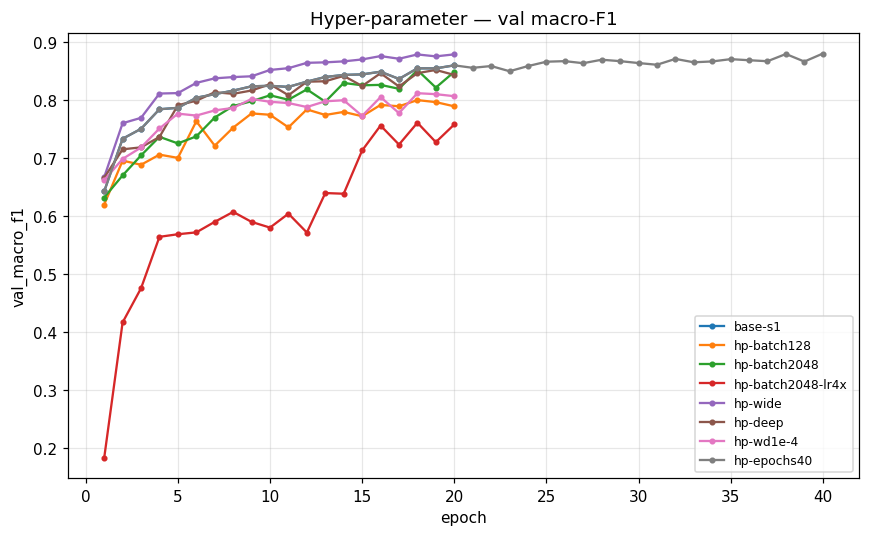

,opt,lr,val_f1,val_acc,best_vloss,best_ep,gap,t_ep,delta_vs_base,beyond_2sigma
exp_id,,,,,,,,,,
base-s1,sgd_momentum,0.3,0.8597,0.9132,0.2208,20,0.0205,1.1406,0.0002,False
hp-batch128,sgd_momentum,0.3,0.7963,0.8759,0.3257,19,0.0182,5.0537,-0.0633,True
hp-batch2048,sgd_momentum,0.3,0.8486,0.9056,0.2368,20,0.0198,0.2926,-0.0110,True
hp-batch2048-lr4x,sgd_momentum,1.2,0.7577,0.8609,0.3420,20,0.0105,0.2831,-0.1018,True
hp-wide,sgd_momentum,0.3,0.8786,0.9252,0.1901,20,0.0248,1.2637,0.0191,True
hp-deep,sgd_momentum,0.3,0.8517,0.9133,0.2203,19,0.0237,1.4312,-0.0078,False
hp-wd1e-4,sgd_momentum,0.3,0.8100,0.8819,0.2843,19,0.0080,1.8122,-0.0496,True
hp-epochs40,sgd_momentum,0.3,0.8793,0.9242,0.1974,38,0.0302,1.7020,0.0197,True


In [12]:
hp = [
    ("hp-batch128",      dict(batch=128),                      "batch 128 (lr giữ nguyên)"),
    ("hp-batch2048",     dict(batch=2048),                     "batch 2048 (lr giữ nguyên)"),
    ("hp-batch2048-lr4x", dict(batch=2048, lr=BASE_LR * 4),    "batch 2048, lr ×4 (quy tắc tuyến tính)"),
    ("hp-wide",          dict(hidden=(512, 256)),              "M-wide 54-512-256-7"),
    ("hp-deep",          dict(hidden=(256, 128, 64)),          "M-deep 54-256-128-64-7"),
    ("hp-wd1e-4",        dict(weight_decay=1e-4),              "weight_decay 1e-4 (L2 trong SGD)"),
    ("hp-epochs40",      dict(epochs=2 * EPOCHS),              "gấp đôi số epoch (đổi cả số bước cập nhật)"),
]
for eid, kw, desc in hp:
    run(exp_id=eid, group="hparam", description=desc, **kw)
hp_ids = [e for e, _, _ in hp]
plot_compare([RESULTS["base-s1"]] + [RESULTS[i] for i in hp_ids], "val_macro_f1", f"{OUT_DIR}/figures/compare_hparam.png", "Hyper-parameter — val macro-F1")
display(Image(f"{OUT_DIR}/figures/compare_hparam.png"))
compare_table(["base-s1"] + hp_ids, BASE_F1, NOISE2)

**Đối chiếu (viết sau khi chạy):** vượt 2σ (0.0105): `hp-wide` (+0.019), `hp-epochs40` (+0.020) tốt hơn; `hp-batch128` (−0.063), `hp-batch2048-lr4x` (−0.102), `hp-wd1e-4` (−0.050) tệ hơn; `hp-batch2048` (−0.011) sát ngưỡng; `hp-deep` (−0.008) trong nhiễu. Số bước/epoch: batch 128 = 2906, 512 = 727, 2048 = 182; thời gian/epoch 5.05 s / 1.14 s / 0.29 s. Khớp dự đoán: wide và 40 epoch giúp (baseline chưa hội tụ/chưa khớp); batch 2048 kém do ít bước. Khác dự đoán: batch 128 tệ hơn (cùng lr 0.3 thì gradient nhiễu hơn, cần lr nhỏ hơn), lr ×4 cho batch 2048 không bù mà còn tệ hơn, `weight_decay=1e-4` hại đáng kể (mô hình đang underfit), deep không giúp trong 20 epoch.

### 3.4 Dropout (`dropout`)
**Dự đoán trước:** baseline chưa quá khớp (khoảng cách train–val loss nhỏ) nên dropout **không giúp** mà làm *chậm* học (thêm nhiễu, giảm năng lực hiệu dụng): q=0.1 ≈ baseline (trong nhiễu), q=0.3/0.5 kém hơn trong 20 epoch.
Khoảng cách train–val (đo ở `eval()`) gần như không đổi/ nhỏ lại. Dropout là thuốc cho quá khớp — chỉ có ích khi val loss bắt đầu tăng.

drop-0.1                 val_f1=0.8418 val_acc=0.9012 best_vloss=0.2395 best_ep=20 step0=2.269 t/ep=1.78s


drop-0.3                 val_f1=0.7523 val_acc=0.8678 best_vloss=0.3184 best_ep=19 step0=2.269 t/ep=1.76s


drop-0.5                 val_f1=0.6118 val_acc=0.8207 best_vloss=0.4191 best_ep=20 step0=2.269 t/ep=1.65s


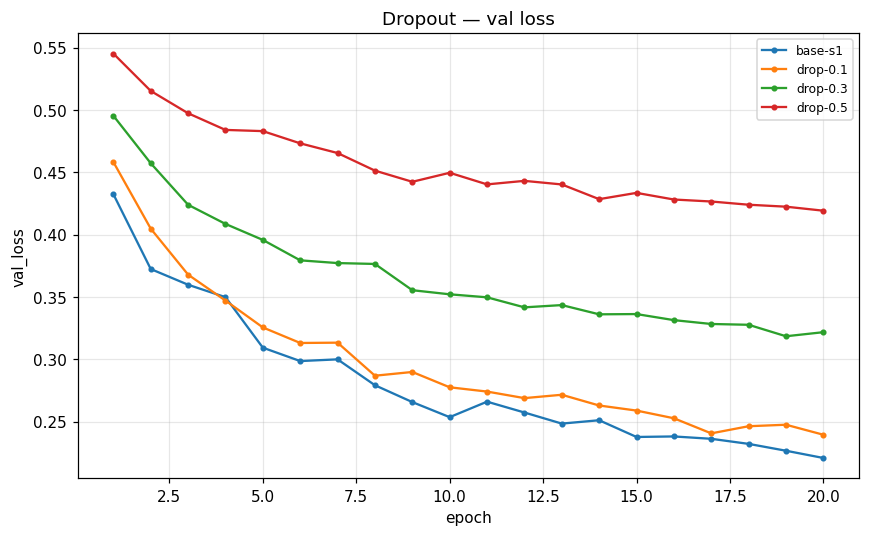

,opt,lr,val_f1,val_acc,best_vloss,best_ep,gap,t_ep,delta_vs_base,beyond_2sigma
exp_id,,,,,,,,,,
base-s1,sgd_momentum,0.3,0.8597,0.9132,0.2208,20,0.0205,1.1406,0.0002,False
drop-0.1,sgd_momentum,0.3,0.8418,0.9012,0.2395,20,0.0097,1.7808,-0.0177,True
drop-0.3,sgd_momentum,0.3,0.7523,0.8678,0.3184,19,0.0041,1.7576,-0.1072,True
drop-0.5,sgd_momentum,0.3,0.6118,0.8207,0.4191,20,0.0016,1.6531,-0.2477,True


In [13]:
for q in (0.1, 0.3, 0.5):
    run(exp_id=f"drop-{q:g}", group="dropout", dropout=q, description=f"Dropout q={q:g} sau mỗi ReLU lớp ẩn")
drop_ids = [f"drop-{q:g}" for q in (0.1, 0.3, 0.5)]
plot_compare([RESULTS["base-s1"]] + [RESULTS[i] for i in drop_ids], "val_loss", f"{OUT_DIR}/figures/compare_dropout.png", "Dropout — val loss")
display(Image(f"{OUT_DIR}/figures/compare_dropout.png"))
compare_table(["base-s1"] + drop_ids, BASE_F1, NOISE2)     # cột `gap` = val_loss − train_loss ở epoch cuối

**Đối chiếu (viết sau khi chạy):** khoảng cách val−train loss: baseline 0.021; q=0.1 → 0.009; q=0.3 → 0.004; q=0.5 → 0.001, nhưng train loss tăng (0.200 → 0.418) nên mô hình chỉ underfit hơn. Baseline không quá khớp (val loss còn giảm ở epoch 20). Dropout hại: macro-F1 0.8418 (Δ −0.018 vượt 2σ) / 0.7523 / 0.6118. Khớp dự đoán, nhưng q=0.1 cũng hại vượt nhiễu thay vì "≈ baseline".

### 3.5 Gradient clipping (`clipping`)
**Dự đoán trước:** ở lr bình thường clipping gần như không đổi gì (nếu `c` lớn hơn hầu hết `grad_norm`) — chênh lệch chỉ là nhiễu. Chọn `c` = trung vị `grad_norm` của baseline để clipping kích hoạt ở khoảng nửa số bước.
Khi tăng lr ×10: không clip → dao động/phân kỳ (NaN) hoặc val loss rất tệ, có các "gai" `grad_norm`; có clip cùng lr → ổn định hơn (clip giới hạn độ dài bước tối đa = lr·c).

baseline grad_norm: trung bình/epoch = [0.389, 0.366, 0.366, 0.367, 0.359, 0.356, 0.357, 0.354, 0.349, 0.347, 0.348, 0.346, 0.345, 0.343, 0.34, 0.34, 0.343, 0.339, 0.34, 0.338]
                    lớn nhất/epoch  = [3.012, 0.669, 0.788, 0.644, 0.856, 0.524, 0.791, 0.677, 0.536, 0.751, 0.655, 0.629, 0.651, 0.735, 0.636, 0.507, 0.821, 0.847, 0.727, 0.651]
-> chọn c = 0.344


clip-c0.34               val_f1=0.8521 val_acc=0.9107 best_vloss=0.2244 best_ep=19 step0=2.269 t/ep=1.64s


clip-hilr-none           val_f1=0.0936 val_acc=0.4876 best_vloss=1.2058 best_ep=19 step0=2.269 t/ep=1.54s


clip-hilr-c0.34          val_f1=0.2943 val_acc=0.6302 best_vloss=0.8859 best_ep=1 step0=2.269 t/ep=1.60s
clip-c0.34 tỉ lệ bước bị clip (TB các epoch) = 0.738
clip-hilr-none tỉ lệ bước bị clip (TB các epoch) = 0.0
clip-hilr-c0.34 tỉ lệ bước bị clip (TB các epoch) = 0.044


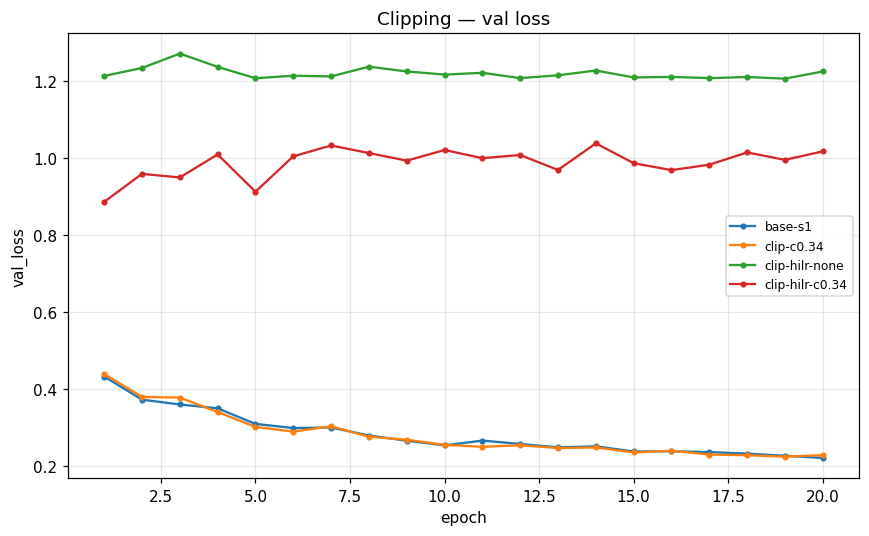

,opt,lr,val_f1,val_acc,best_vloss,best_ep,gap,t_ep,delta_vs_base,beyond_2sigma
exp_id,,,,,,,,,,
base-s1,sgd_momentum,0.3,0.8597,0.9132,0.2208,20,0.0205,1.1406,0.0002,False
clip-c0.34,sgd_momentum,0.3,0.8521,0.9107,0.2244,19,0.0229,1.6398,-0.0074,False
clip-hilr-none,sgd_momentum,3.0,0.0936,0.4876,1.2058,19,0.0009,1.5425,-0.7659,True
clip-hilr-c0.34,sgd_momentum,3.0,0.2943,0.6302,0.8859,1,0.0026,1.6001,-0.5653,True


In [14]:
gn = RESULTS["base-s1"]["history"]["grad_norm_p50"]
C = float(f"{np.median(gn):.3g}")          # c chọn từ grad_norm của baseline: trung vị của trung vị mỗi epoch
print("baseline grad_norm: trung bình/epoch =", np.round(RESULTS["base-s1"]["history"]["grad_norm"], 3).tolist())
print("                    lớn nhất/epoch  =", np.round(RESULTS["base-s1"]["history"]["grad_norm_max"], 3).tolist())
print(f"-> chọn c = {C:.3g}")
run(exp_id=f"clip-c{C:.2g}", group="clipping", clip_norm=C, description=f"clip_norm c={C:.3g} ở lr baseline")
run(exp_id="clip-hilr-none", group="clipping", lr=BASE_LR * 10, description=f"lr ×10 ({BASE_LR * 10:g}), KHÔNG clip")
run(exp_id=f"clip-hilr-c{C:.2g}", group="clipping", lr=BASE_LR * 10, clip_norm=C, description=f"lr ×10 ({BASE_LR * 10:g}), clip c={C:.3g}")
clip_ids = [i for i in RUN_ORDER if i.startswith("clip-")]
for i in clip_ids: print(i, "tỉ lệ bước bị clip (TB các epoch) =", round(RESULTS[i]["summary"]["clip_frac_mean"], 3))
plot_compare([RESULTS["base-s1"]] + [RESULTS[i] for i in clip_ids], "val_loss", f"{OUT_DIR}/figures/compare_clipping.png", "Clipping — val loss")
plot_compare([RESULTS["base-s1"]] + [RESULTS[i] for i in clip_ids], "grad_norm_max", f"{OUT_DIR}/figures/compare_clipping_gradnorm.png", "Clipping — grad_norm lớn nhất mỗi epoch (trước clip)")
display(Image(f"{OUT_DIR}/figures/compare_clipping.png"))
compare_table(["base-s1"] + clip_ids, BASE_F1, NOISE2)

**Đối chiếu (viết sau khi chạy):** ở lr thường, `clip-c0.34` (c = trung vị grad_norm ≈ 0.344) bị clip ở 74% số bước (83–89% ở các epoch đầu), nhiều hơn dự đoán ≈ 50% vì phân bố grad_norm rất hẹp; macro-F1 0.8521 (Δ −0.007, trong nhiễu). Ở lr ×10 = 3.0: không clip → `grad_norm_max` epoch 1 = 294, mạng sụp về lớp đa số (macro-F1 0.0936, acc 0.4876), không có NaN; có clip → macro-F1 0.294 (clip 42% bước epoch 1), tốt hơn nhưng vẫn rất tệ và dao động. Khác dự đoán: clipping không cứu được hoàn toàn vì bước tối đa lr·c ≈ 1.03 vẫn quá lớn.

### 3.6 Mixed precision (`amp`)
**Dự đoán trước:** tham số vẫn FP32; chỉ phép toán được hạ độ chính xác. Với mạng nhỏ này (~48k tham số, batch 512) thời gian bị chi phối bởi chi phí gọi kernel, nên FP16/BF16 **không nhanh hơn** (thậm chí chậm hơn do overhead autocast/GradScaler) và bộ nhớ cực đại gần như không đổi (bị dữ liệu trên GPU chi phối); độ chính xác ≈ FP32 (trong nhiễu).
FP16 cần GradScaler vì khoảng biểu diễn hẹp (gradient nhỏ dễ underflow); BF16 có cùng số mũ với FP32 (8 bit) nên thường không cần.

amp-fp16                 val_f1=0.8617 val_acc=0.9113 best_vloss=0.2189 best_ep=19 step0=2.269 t/ep=1.96s


amp-bf16                 val_f1=0.8624 val_acc=0.9133 best_vloss=0.2182 best_ep=20 step0=2.269 t/ep=1.64s


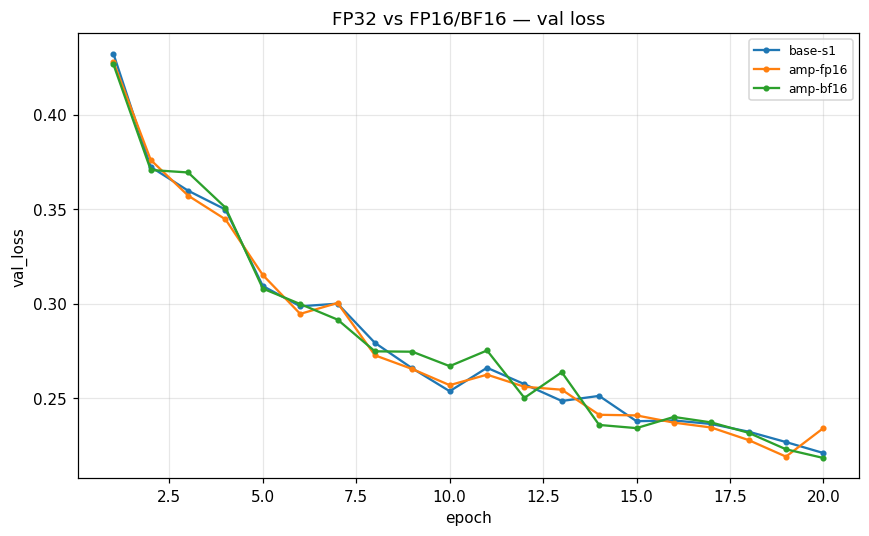

thời gian/epoch FP32 (TB base-s2..): 1.12s
          t_epoch  peak_MB  skipped_steps
base-s2     1.127  179.092            0.0
amp-fp16    1.958  185.233            5.0
amp-bf16    1.642  185.416            0.0


,opt,lr,val_f1,val_acc,best_vloss,best_ep,gap,t_ep,delta_vs_base,beyond_2sigma
exp_id,,,,,,,,,,
base-s1,sgd_momentum,0.3,0.8597,0.9132,0.2208,20,0.0205,1.1406,0.0002,False
amp-fp16,sgd_momentum,0.3,0.8617,0.9113,0.2189,19,0.0211,1.9582,0.0022,False
amp-bf16,sgd_momentum,0.3,0.8624,0.9133,0.2182,20,0.0202,1.6419,0.0029,False


In [15]:
amp_ids = []
for prec in ("fp16", "bf16"):
    try:
        run(exp_id=f"amp-{prec}", group="amp", precision=prec, description=f"Mixed precision {prec} (autocast" + (" + GradScaler)" if prec == "fp16" else ")"))
        amp_ids.append(f"amp-{prec}")
    except RuntimeError as e:     # ví dụ không có GPU/không hỗ trợ bf16: ghi lý do vào báo cáo thay vì dừng notebook
        print(f"[bỏ qua amp-{prec}] {e}")
if amp_ids:
    plot_compare([RESULTS["base-s1"]] + [RESULTS[i] for i in amp_ids], "val_loss", f"{OUT_DIR}/figures/compare_amp.png", "FP32 vs FP16/BF16 — val loss")
    display(Image(f"{OUT_DIR}/figures/compare_amp.png"))
    t_base = np.mean([RESULTS[i]["summary"]["time_per_epoch_s"] for i in base_ids[1:]])   # bỏ base-s1 (có thể gồm thời gian khởi động CUDA)
    print(f"thời gian/epoch FP32 (TB base-s2..): {t_base:.2f}s")
    print(pd.DataFrame({i: dict(t_epoch=RESULTS[i]["summary"]["time_per_epoch_s"], peak_MB=RESULTS[i]["summary"]["peak_mem_MB"],
                                skipped_steps=RESULTS[i]["summary"]["skipped_steps"]) for i in ["base-s2"] + amp_ids}).T.round(3))
    display(compare_table(["base-s1"] + amp_ids, BASE_F1, NOISE2))

**Đối chiếu (viết sau khi chạy):** thời gian/epoch 1.14 s (FP32) / 1.96 s (FP16) / 1.64 s (BF16): **chậm hơn**; bộ nhớ 179 / 185 / 185 MB (gần như không đổi); val macro-F1 0.8597 / 0.8617 / 0.8624 (trong nhiễu). FP16 bỏ qua 5 bước (`skipped_steps` = 5, GradScaler giảm scale lúc đầu), BF16 không. Khớp dự đoán: mạng nhỏ bị chi phối bởi chi phí gọi kernel và overhead autocast/GradScaler, dữ liệu trên GPU chi phối bộ nhớ.

### 3.7 Khởi tạo tham số (`init`)
**Dự đoán trước:** `zeros`: mọi nơ-ron trong một lớp đối xứng — với W=0 thì kích hoạt ẩn = ReLU(0) = 0 nên gradient của mọi W (lớp ẩn *và* lớp ra) = 0, chỉ bias lớp ra học được ⇒ mạng chỉ học tần suất lớp (acc ≈ 0.4876, macro-F1 ≈ 0.09). `normal` (std 0.01) làm kích hoạt co dần theo lớp (std lớp sau ≈ 0.01·√n·std lớp trước ≪ 1) → gradient rất nhỏ → học chậm trong 20 epoch.
`xavier` (Var=2/(n_in+n_out)) và `default` (Kaiming-uniform a=√5, Var≈1/(3 n_in)) học được, nhưng với ReLU He (Var=2/n_in) giữ phương sai kích hoạt tốt nhất; với mạng chỉ 3 lớp, chênh lệch giữa He/Xavier/default nhỏ (có thể nằm trong nhiễu).

init-zeros               val_f1=0.0936 val_acc=0.4876 best_vloss=1.2053 best_ep=6 step0=1.946 t/ep=1.37s


init-normal              val_f1=0.8639 val_acc=0.9122 best_vloss=0.2225 best_ep=19 step0=1.946 t/ep=1.48s


init-xavier              val_f1=0.8656 val_acc=0.9136 best_vloss=0.2175 best_ep=20 step0=2.022 t/ep=1.42s


init-default             val_f1=0.8591 val_acc=0.9137 best_vloss=0.2212 best_ep=19 step0=1.983 t/ep=1.39s
độ lệch chuẩn kích hoạt (sau mỗi nn.Linear, bước 0, 1 lô val) và loss bước 0  [base-s1 = He]:
              step0_loss   std_L1   std_L2   std_L3
base-s1          2.26906  0.66090  0.64036  0.57728
init-zeros       1.94591  0.00000  0.00000  0.00000
init-normal      1.94600  0.03434  0.00376  0.00027
init-xavier      2.02218  0.27584  0.21822  0.19156
init-default     1.98304  0.27370  0.11298  0.05851


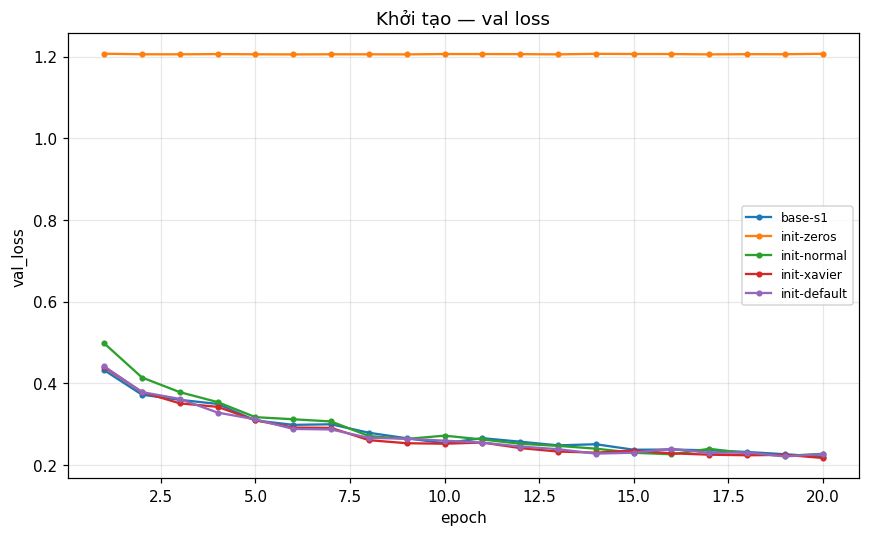

,opt,lr,val_f1,val_acc,best_vloss,best_ep,gap,t_ep,delta_vs_base,beyond_2sigma
exp_id,,,,,,,,,,
base-s1,sgd_momentum,0.3,0.8597,0.9132,0.2208,20,0.0205,1.1406,0.0002,False
init-zeros,sgd_momentum,0.3,0.0936,0.4876,1.2053,6,0.0012,1.3728,-0.7659,True
init-normal,sgd_momentum,0.3,0.8639,0.9122,0.2225,19,0.0221,1.4770,0.0043,False
init-xavier,sgd_momentum,0.3,0.8656,0.9136,0.2175,20,0.0195,1.4175,0.0061,False
init-default,sgd_momentum,0.3,0.8591,0.9137,0.2212,19,0.0219,1.3860,-0.0004,False


In [16]:
for init in ("zeros", "normal", "xavier", "default"):
    run(exp_id=f"init-{init}", group="init", init=init, description=f"Khởi tạo {init} (bias=0, trừ default)" if init != "default" else "Khởi tạo mặc định của nn.Linear (KHÔNG phải He)")
init_ids = [f"init-{i}" for i in ("zeros", "normal", "xavier", "default")]
tab = {i: dict(step0_loss=RESULTS[i]["summary"]["step0_loss"], **{f"std_L{k+1}": v for k, v in enumerate(RESULTS[i]["summary"]["act_std_step0"])}) for i in ["base-s1"] + init_ids}
print("độ lệch chuẩn kích hoạt (sau mỗi nn.Linear, bước 0, 1 lô val) và loss bước 0  [base-s1 = He]:")
print(pd.DataFrame(tab).T.round(5))
plot_compare([RESULTS["base-s1"]] + [RESULTS[i] for i in init_ids], "val_loss", f"{OUT_DIR}/figures/compare_init.png", "Khởi tạo — val loss")
display(Image(f"{OUT_DIR}/figures/compare_init.png"))
compare_table(["base-s1"] + init_ids, BASE_F1, NOISE2)

**Đối chiếu (viết sau khi chạy):** `zeros` không học: gradient lớp ẩn = 0 (ReLU(0)=0, đối xứng), chỉ bias lớp ra học → acc 0.4876, macro-F1 0.0936. `normal` (σ=0.01): std kích hoạt co 0.034 → 0.0038 → 0.00027 (so với He 0.274 → 0.113 → 0.059, xavier 0.276 → 0.218 → 0.192), nhưng vẫn học bình thường (0.8639, trong nhiễu) — khác dự đoán "học chậm". He/default/xavier (0.859 / 0.859 / 0.866) không khác nhau vượt 2σ: mạng 3 lớp chưa đủ sâu để thấy khác biệt.

### 3.8 Kết hợp → cấu hình cuối cùng (chọn **chỉ bằng val**)
Ứng viên: (a) bộ tối ưu + lr tốt nhất ở nhóm *optimizer*; (b) (a) + `M-wide`; (c) (a) + `M-wide` + gấp đôi epoch. Chọn ứng viên có **val macro-F1** cao nhất, rồi chạy 3 seed (`final-s1..3`).
Không dùng eval ở bước này.

In [17]:
best_opt_id = best_of(list(BEST_ID.values()))
oc = RESULTS[best_opt_id]["cfg"]
OPTKW = dict(optimizer=oc["optimizer"], lr=oc["lr"], weight_decay=oc["weight_decay"])
print("bộ tối ưu tốt nhất theo val:", best_opt_id)
cands = {
    "fin-cand-opt":     dict(**OPTKW),
    "fin-cand-wide":    dict(**OPTKW, hidden=(512, 256)),
    "fin-cand-wide-2x": dict(**OPTKW, hidden=(512, 256), epochs=2 * EPOCHS),
}
for eid, kw in cands.items():
    run(exp_id=eid, group="other", description=f"Ứng viên cấu hình cuối: {kw}", **kw)
FINAL_CAND = best_of(list(cands))
fc = RESULTS[FINAL_CAND]["cfg"]
FINAL_KW = {k: fc[k] for k in ("optimizer", "lr", "weight_decay", "hidden", "epochs")}
print("\n-> cấu hình cuối cùng (chọn theo val):", FINAL_CAND, FINAL_KW)
compare_table(list(cands), BASE_F1, NOISE2)

bộ tối ưu tốt nhất theo val: opt-adam-lr0.003


fin-cand-opt             val_f1=0.8840 val_acc=0.9183 best_vloss=0.2052 best_ep=20 step0=2.269 t/ep=1.53s


fin-cand-wide            val_f1=0.8928 val_acc=0.9310 best_vloss=0.1784 best_ep=20 step0=1.918 t/ep=1.55s


fin-cand-wide-2x         val_f1=0.9024 val_acc=0.9406 best_vloss=0.1601 best_ep=38 step0=1.918 t/ep=1.34s

-> cấu hình cuối cùng (chọn theo val): fin-cand-wide-2x {'optimizer': 'adam', 'lr': 0.003, 'weight_decay': 0.0, 'hidden': (512, 256), 'epochs': 40}


,opt,lr,val_f1,val_acc,best_vloss,best_ep,gap,t_ep,delta_vs_base,beyond_2sigma
exp_id,,,,,,,,,,
fin-cand-opt,adam,0.003,0.8840,0.9183,0.2052,20,0.0227,1.5334,0.0245,True
fin-cand-wide,adam,0.003,0.8928,0.9310,0.1784,20,0.0330,1.5523,0.0333,True
fin-cand-wide-2x,adam,0.003,0.9024,0.9406,0.1601,38,0.0497,1.3419,0.0429,True


final-s1                 val_f1=0.9024 val_acc=0.9406 best_vloss=0.1601 best_ep=38 step0=1.918 t/ep=1.28s


final-s2                 val_f1=0.9071 val_acc=0.9406 best_vloss=0.1589 best_ep=39 step0=2.652 t/ep=1.27s


final-s3                 val_f1=0.9087 val_acc=0.9415 best_vloss=0.1572 best_ep=39 step0=2.788 t/ep=1.28s


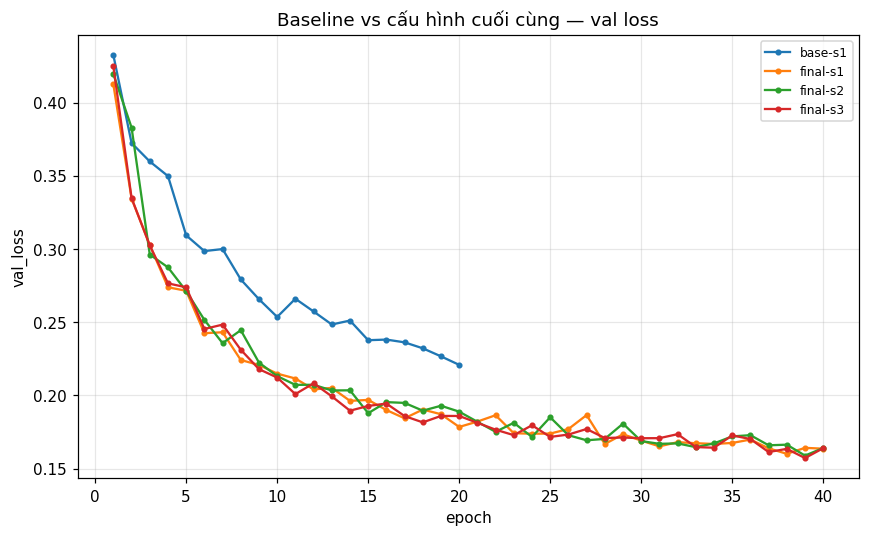

cấu hình cuối: val macro-F1 = 0.9061 ± 0.0033 | baseline = 0.8595 ± 0.0052 | Δ = +0.0465 (2σ = 0.0105)


In [18]:
for s in (1, 2, 3):
    run(exp_id=f"final-s{s}", group="final", seed=s, description=f"Cấu hình cuối cùng ({FINAL_CAND}), seed {s}", **FINAL_KW)
final_ids = [f"final-s{s}" for s in (1, 2, 3)]
plot_compare([RESULTS["base-s1"]] + [RESULTS[i] for i in final_ids], "val_loss", f"{OUT_DIR}/figures/compare_final.png", "Baseline vs cấu hình cuối cùng — val loss")
display(Image(f"{OUT_DIR}/figures/compare_final.png"))
ff = np.array([RESULTS[i]["summary"]["val_macro_f1"] for i in final_ids])
print(f"cấu hình cuối: val macro-F1 = {ff.mean():.4f} ± {ff.std(ddof=1):.4f} | baseline = {BASE_F1:.4f} ± {SIGMA:.4f} | Δ = {ff.mean() - BASE_F1:+.4f} (2σ = {NOISE2:.4f})")

## Part 4 — Đánh giá cuối trên eval, bảng và nộp bài
Chỉ **sau khi** cấu hình cuối đã được chọn bằng val ở trên. Eval chỉ dùng cho baseline (5 seed) và cấu hình cuối (3 seed); **không chỉnh cấu hình sau khi thấy điểm eval**.
File nộp `predictions_eval.csv` = dự đoán của `final-s1`; các dự đoán khác ghi vào thư mục tạm (không nộp).

In [19]:
TMP = tempfile.mkdtemp(prefix="lab_eval_")
EVAL = {}
def eval_on_eval(exp_id, submit=False):
    pred = f"{OUT_DIR}/predictions_eval.csv" if submit else os.path.join(TMP, f"pred_{exp_id}.csv")
    out = f"{OUT_DIR}/eval_result.json" if submit else os.path.join(TMP, f"eval_{exp_id}.json")
    r = RESULTS[exp_id]
    final_eval(r["cfg"], r, data, pred)       # nạp best_state (epoch val loss thấp nhất), dự đoán TOÀN BỘ eval ở eval mode
    p = subprocess.run([sys.executable, "scripts/evaluate.py", "--pred", os.path.abspath(pred), "--out", os.path.abspath(out)],
                       cwd=REPO_ROOT, capture_output=True, text=True, encoding="utf-8")
    assert p.returncode == 0, p.stdout + p.stderr
    if submit: print(p.stdout)
    res = json.load(open(out, encoding="utf-8"))
    EVAL[exp_id] = dict(accuracy=res["accuracy"], macro_f1=res["macro_f1"])
    return res

for i in base_ids: eval_on_eval(i)
for i in final_ids[1:]: eval_on_eval(i)
res_final = eval_on_eval("final-s1", submit=True)       # <- file nộp: ../predictions_eval.csv và ../eval_result.json
json.dump(EVAL, open(f"{OUT_DIR}/results/eval_scores.json", "w"), indent=1)

b = np.array([EVAL[i]["macro_f1"] for i in base_ids]); f_ = np.array([EVAL[i]["macro_f1"] for i in final_ids])
print(pd.DataFrame({"exp_id": base_ids + final_ids, **{k: [EVAL[i][k] for i in base_ids + final_ids] for k in ("accuracy", "macro_f1")}}).round(4).to_string(index=False))
print(f"\neval macro-F1  baseline = {b.mean():.4f} ± {b.std(ddof=1):.4f}   cuối = {f_.mean():.4f} ± {f_.std(ddof=1):.4f}   Δ = {f_.mean() - b.mean():+.4f}")
print(f"val  macro-F1  baseline = {BASE_F1:.4f}   cuối = {ff.mean():.4f}   (val vs eval cho thấy val là ước lượng tốt của eval nếu hai số gần nhau)")

n_eval = 116203
accuracy = 0.9406
macro_f1 = 0.9073   <- chỉ số chính

lớp  support  precision  recall    f1
  0    42368     0.9346  0.9419  0.9382
  1    56661     0.9490  0.9499  0.9494
  2     7151     0.9576  0.9196  0.9382
  3      549     0.8680  0.8506  0.8592
  4     1899     0.8948  0.7657  0.8252
  5     3473     0.8770  0.9093  0.8928
  6     4102     0.9418  0.9542  0.9479

ma trận nhầm lẫn (hàng = thật, cột = dự đoán):
       0      1     2    3     4     5     6
0  39905   2231     0    0    21     0   211
1   2549  53822    66    0   121    72    31
2      3    162  6576   52    24   334     0
3      0      0    58  467     0    24     0
4     59    362    11    0  1454    13     0
5     18    117   156   19     5  3158     0
6    165     23     0    0     0     0  3914

đã ghi D:\Learning\AI_in_Action\Track4_ComputerVision\Day01\K4-Track4-Day1-Neuralnetwork\submission_2A202602796\eval_result.json

  exp_id  accuracy  macro_f1
 base-s1    0.9116    0.8598
 base-s2    0.

In [20]:
# ---- Phân tích lỗi theo lớp (từ eval_result.json của final-s1, file nộp)
NAMES = ["Spruce/Fir", "Lodgepole", "Ponderosa", "Cottonwood", "Aspen", "Douglas-fir", "Krummholz"]
pc = pd.DataFrame(res_final["per_class"]).set_index("cls"); pc.insert(0, "name", NAMES)
print(pc.round(4).to_string())
cm = np.array(res_final["confusion_matrix"])
print("\nma trận nhầm lẫn (hàng = thật, cột = dự đoán):"); print(pd.DataFrame(cm).to_string())
cmn = cm / cm.sum(1, keepdims=True)
print("\nchuẩn hoá theo hàng (recall trên đường chéo; ô ngoài đường chéo = tỉ lệ bị nhầm sang lớp đó):"); print(pd.DataFrame(cmn).round(3).to_string())
worst = int(pc["f1"].idxmin()); conf = np.where(np.arange(7) == worst, -1, cmn[worst]).argmax()
print(f"\nlớp khó nhất: {worst} ({NAMES[worst]}), F1 = {pc.loc[worst, 'f1']:.4f}, support = {pc.loc[worst, 'support']}; hay bị nhầm nhất với lớp {conf} ({NAMES[conf]}): {cmn[worst, conf]:.1%}")

            name  support  precision  recall      f1
cls                                                 
0     Spruce/Fir    42368     0.9346  0.9419  0.9382
1      Lodgepole    56661     0.9490  0.9499  0.9494
2      Ponderosa     7151     0.9576  0.9196  0.9382
3     Cottonwood      549     0.8680  0.8506  0.8592
4          Aspen     1899     0.8948  0.7657  0.8252
5    Douglas-fir     3473     0.8770  0.9093  0.8928
6      Krummholz     4102     0.9418  0.9542  0.9479

ma trận nhầm lẫn (hàng = thật, cột = dự đoán):
       0      1     2    3     4     5     6
0  39905   2231     0    0    21     0   211
1   2549  53822    66    0   121    72    31
2      3    162  6576   52    24   334     0
3      0      0    58  467     0    24     0
4     59    362    11    0  1454    13     0
5     18    117   156   19     5  3158     0
6    165     23     0    0     0     0  3914

chuẩn hoá theo hàng (recall trên đường chéo; ô ngoài đường chéo = tỉ lệ bị nhầm sang lớp đó):
       0      1     

**Phân tích lỗi (tự viết, dựa vào bảng trên):** lớp khó nhất là 4 (Aspen; F1 = 0.8252, recall 0.766), hay bị nhầm với lớp 1 (Lodgepole): 19.1% mẫu Aspen bị dự đoán thành Lodgepole. Lý giải: lớp 4 hiếm (1.6% dữ liệu) và có đặc trưng địa hình/độ cao gần Lodgepole nên CE không trọng số kéo về lớp đa số; lớp 3 (Cottonwood, 0.47%) hay nhầm với lớp 2 (10.6%); một cách cải thiện: trọng số lớp / focal loss, huấn luyện lâu hơn, mạng rộng hơn.

In [21]:
# ---- Bảng experiments.xlsx (điền bằng code từ results/*.json) + kiểm tra số ảnh = số dòng
res = {r["cfg"]["exp_id"]: r for r in load_results(f"{OUT_DIR}/results")}
assert set(res) == set(RUN_ORDER), "results/ không khớp các lần chạy trong notebook (còn file cũ?)"
def auto_notes(i):
    s = res[i]["summary"]
    n = f"act_std_step0={[round(v, 4) for v in s['act_std_step0']]}; clip_frac={s['clip_frac_mean']:.3f}; skipped_steps={s['skipped_steps']}; epochs_run={s['n_epochs_run']}"
    if res[i]["cfg"]["precision"] != "fp32": n += "; peak_mem gồm cả dữ liệu nằm trên GPU"
    if s["diverged"]: n += "; DIVERGED (loss NaN/inf) -> dừng sớm"
    return n
rows = [to_row(res[i], EVAL.get(i), auto_notes(i)) for i in RUN_ORDER]

def summ(g):   # nhận xét ngắn sinh tự động (sự thật đo được); bạn có thể bổ sung diễn giải trong Excel
    ids = [i for i in RUN_ORDER if res[i]["cfg"]["group"] == g and res[i]["summary"]["val_macro_f1"] is not None]
    if not ids: return ""
    b_ = max(ids, key=lambda i: res[i]["summary"]["val_macro_f1"])
    return f"tốt nhất: {b_} (val macro-F1 {res[b_]['summary']['val_macro_f1']:.4f}); baseline {BASE_F1:.4f} ± {SIGMA:.4f} (2σ = {NOISE2:.4f})"
summary_notes = {g: summ(g) for g in ("baseline", "loss", "optimizer", "hparam", "dropout", "clipping", "amp", "init", "final", "other")}
write_xlsx(rows, f"{REPO_ROOT}/templates/experiment_table_template.xlsx", f"{OUT_DIR}/experiments.xlsx", seed_ids=base_ids, summary_notes=summary_notes)

figs = sorted(f for f in os.listdir(f"{OUT_DIR}/figures") if not f.startswith("compare_"))
assert figs == sorted(f"{i}.png" for i in RUN_ORDER), "số ảnh figures/<exp_id>.png phải bằng số dòng của bảng"
print(f"experiments.xlsx: {len(rows)} dòng; figures/: {len(figs)} ảnh thí nghiệm + {len(os.listdir(f'{OUT_DIR}/figures')) - len(figs)} ảnh compare_*")

experiments.xlsx: 51 dòng; figures/: 51 ảnh thí nghiệm + 13 ảnh compare_*


In [22]:
# ---- Bảng markdown dán vào REPORT.md
t = lambda i, k: RESULTS[i]["summary"][k]
print("| Cấu hình | Seed nộp | val macro-F1 | **eval macro-F1** | eval accuracy |\n|---|---|---|---|---|")
print(f"| Baseline (TB 5 seed) | s1 | {BASE_F1:.4f} | {b.mean():.4f} ± {b.std(ddof=1):.4f} | {np.mean([EVAL[i]['accuracy'] for i in base_ids]):.4f} |")
print(f"| Cấu hình cuối cùng {FINAL_KW} (TB 3 seed) | s1 | {ff.mean():.4f} | {f_.mean():.4f} ± {f_.std(ddof=1):.4f} | {np.mean([EVAL[i]['accuracy'] for i in final_ids]):.4f} |")
print(f"\nfinal-s1 (file nộp): eval macro-F1 = {res_final['macro_f1']:.4f}, accuracy = {res_final['accuracy']:.4f}")
print("\n| Lớp | support | precision | recall | F1 |\n|---|---|---|---|---|")
for c, r in pc.iterrows(): print(f"| {c} ({r['name']}) | {int(r['support'])} | {r['precision']:.4f} | {r['recall']:.4f} | {r['f1']:.4f} |")

| Cấu hình | Seed nộp | val macro-F1 | **eval macro-F1** | eval accuracy |
|---|---|---|---|---|
| Baseline (TB 5 seed) | s1 | 0.8595 | 0.8613 ± 0.0032 | 0.9118 |
| Cấu hình cuối cùng {'optimizer': 'adam', 'lr': 0.003, 'weight_decay': 0.0, 'hidden': (512, 256), 'epochs': 40} (TB 3 seed) | s1 | 0.9061 | 0.9064 ± 0.0008 | 0.9405 |

final-s1 (file nộp): eval macro-F1 = 0.9073, accuracy = 0.9406

| Lớp | support | precision | recall | F1 |
|---|---|---|---|---|
| 0 (Spruce/Fir) | 42368 | 0.9346 | 0.9419 | 0.9382 |
| 1 (Lodgepole) | 56661 | 0.9490 | 0.9499 | 0.9494 |
| 2 (Ponderosa) | 7151 | 0.9576 | 0.9196 | 0.9382 |
| 3 (Cottonwood) | 549 | 0.8680 | 0.8506 | 0.8592 |
| 4 (Aspen) | 1899 | 0.8948 | 0.7657 | 0.8252 |
| 5 (Douglas-fir) | 3473 | 0.8770 | 0.9093 | 0.8928 |
| 6 (Krummholz) | 4102 | 0.9418 | 0.9542 | 0.9479 |


**Kết luận Part 4 (tự viết):** cấu hình cuối (Adam 3e-3, 512-256, 40 epoch) đạt eval macro-F1 0.9064 ± 0.0008 so với baseline 0.8613 ± 0.0032: Δ = +0.0450, gấp ≈ 4 lần 2σ (0.0105) → vượt nhiễu. Val (0.8595 / 0.9061) và eval (0.8613 / 0.9064) rất gần nhau nên val là ước lượng tốt. Seed nộp là final-s1 (eval macro-F1 0.9073, acc 0.9406). Tiếp theo: viết `REPORT.md` (xem `REPORT.md` trong thư mục nộp), mở `experiments.xlsx` bằng Excel để công thức tính lại.